In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

FEATURES_PATH = Path(
    "../data/processed/microservices_sample/"
    "microservices_trace_features.csv"
)

OUTPUT_DIR = Path(
    "../artifacts/figures/microservices_exploratory"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
### Célula 2 — carregar dados

features = pd.read_csv(FEATURES_PATH)

features.shape

(19976, 15)

In [3]:
### Célula 3 — cobertura dos sinais

signal_columns = [
    "error_count",
    "warn_count",
    "has_stack_trace",
    "text_signal_count",
    "has_any_signal",
]

coverage = pd.DataFrame({
    "signal": signal_columns,
    "traces_with_signal": [
        int(features[column].gt(0).sum())
        for column in signal_columns
    ],
})

coverage["percentage"] = (
    coverage["traces_with_signal"]
    / len(features)
    * 100
)

coverage

,signal,traces_with_signal,percentage
0,error_count,3219,16.114337
1,warn_count,4251,21.280537
2,has_stack_trace,202,1.011213
3,text_signal_count,308,1.541850
4,has_any_signal,5380,26.932319


In [4]:
### Célula 4 — estatísticas descritivas

features.drop(
    columns=["tc_trace_id"]
).describe().T

,count,mean,std,min,25%,50%,75%,max
event_count,19976.0,7.746095,119.900150,1.0,1.0,2.0,4.0,14376.0
info_count,19976.0,7.027583,119.022163,0.0,1.0,1.0,4.0,14376.0
warn_count,19976.0,0.535843,5.105673,0.0,0.0,0.0,0.0,400.0
error_count,19976.0,0.182669,0.607028,0.0,0.0,0.0,0.0,54.0
has_stack_trace,19976.0,0.010112,0.100052,0.0,0.0,0.0,0.0,1.0
has_exception_term,19976.0,0.002453,0.049468,0.0,0.0,0.0,0.0,1.0
has_failed_term,19976.0,0.000451,0.021222,0.0,0.0,0.0,0.0,1.0
has_timeout_term,19976.0,0.002353,0.048450,0.0,0.0,0.0,0.0,1.0
has_error_term,19976.0,0.013166,0.113987,0.0,0.0,0.0,0.0,1.0
service_count,19976.0,1.290649,1.584318,1.0,1.0,1.0,1.0,53.0


In [5]:
### Célula 5 — combinações

def signal_profile(row):
    profile = []

    if row["error_count"] > 0:
        profile.append("ERROR")

    if row["warn_count"] > 0:
        profile.append("WARN")

    if row["has_stack_trace"] > 0:
        profile.append("STACK_TRACE")

    if row["text_signal_count"] > 0:
        profile.append("TEXT")

    return "+".join(profile) if profile else "NONE"


features["signal_profile"] = features.apply(
    signal_profile,
    axis=1,
)

combinations = (
    features["signal_profile"]
    .value_counts()
    .rename_axis("signal_profile")
    .reset_index(name="trace_count")
)

combinations["percentage"] = (
    combinations["trace_count"]
    / len(features)
    * 100
)

combinations.head(20)

,signal_profile,trace_count,percentage
0,NONE,14596,73.067681
1,WARN,2064,10.332399
2,ERROR+WARN,2032,10.172207
3,ERROR,955,4.780737
4,ERROR+STACK_TRACE+TEXT,146,0.730877
5,WARN+TEXT,69,0.345414
6,ERROR+WARN+STACK_TRACE+TEXT,34,0.170204
7,ERROR+WARN+TEXT,31,0.155186
8,TEXT,27,0.135162
9,ERROR+WARN+STACK_TRACE,20,0.100120


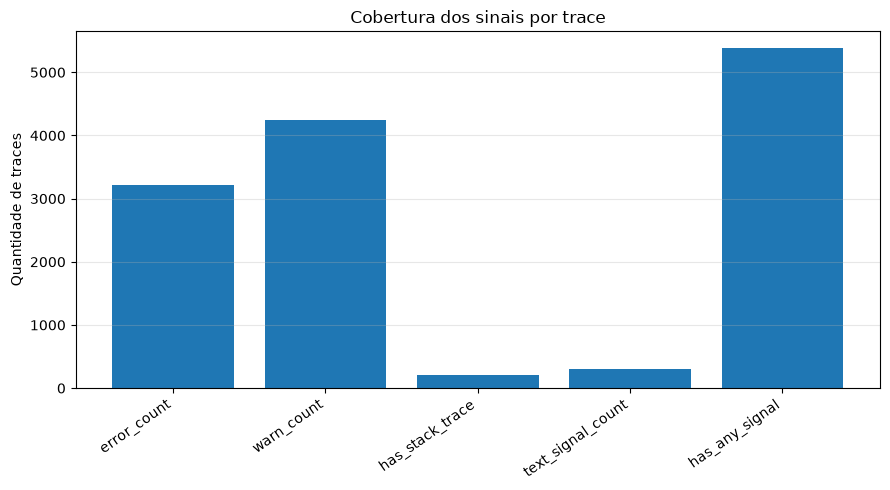

In [6]:
 ### Célula 6 — gráfico dos sinais

plt.figure(figsize=(9, 5))

plt.bar(
    coverage["signal"],
    coverage["traces_with_signal"],
)

plt.xticks(rotation=35, ha="right")
plt.ylabel("Quantidade de traces")
plt.title("Cobertura dos sinais por trace")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "signal_coverage.png",
    dpi=300,
)

plt.show()

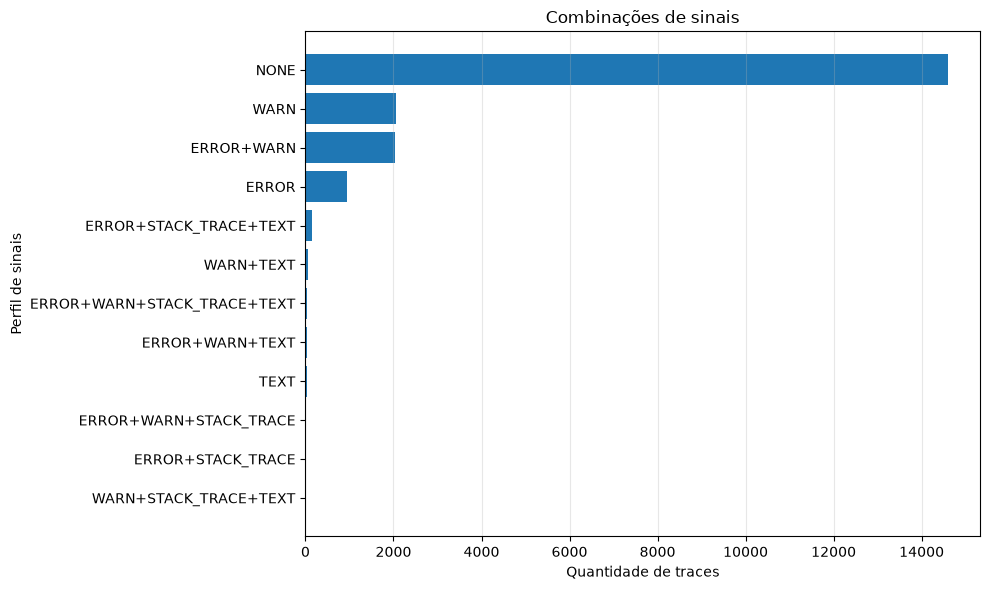

In [7]:
### Célula 7 — gráfico das combinações

top = combinations.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top["signal_profile"].iloc[::-1],
    top["trace_count"].iloc[::-1],
)

plt.xlabel("Quantidade de traces")
plt.ylabel("Perfil de sinais")
plt.title("Combinações de sinais")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "signal_combinations.png",
    dpi=300,
)

plt.show()

In [8]:
### Célula 8 — correlação

correlation = features.drop(
    columns=["tc_trace_id", "signal_profile"],
).corr()

correlation

,event_count,info_count,warn_count,error_count,has_stack_trace,has_exception_term,has_failed_term,has_timeout_term,has_error_term,service_count,error_rate,warn_rate,text_signal_count,has_any_signal
event_count,1.000000,0.999088,0.189645,0.030029,0.020354,0.008782,0.004334,0.066753,0.064970,0.220061,-0.015412,-0.011778,0.071498,0.042674
info_count,0.999088,1.000000,0.147856,0.022702,0.016935,0.007497,0.003900,0.063111,0.055711,0.195514,-0.018999,-0.017181,0.063144,0.033045
warn_count,0.189645,0.147856,1.000000,0.057064,0.034179,0.012437,0.007013,0.092855,0.184951,0.589783,0.000477,0.115531,0.168685,0.172871
error_count,0.030029,0.022702,0.057064,1.000000,0.412228,0.160132,0.032473,0.029643,0.353769,0.170658,0.677092,0.070752,0.322529,0.495671
has_stack_trace,0.020354,0.016935,0.034179,0.412228,1.000000,0.480509,0.210057,0.036402,0.769686,0.045570,0.410218,-0.027409,0.753791,0.166477
has_exception_term,0.008782,0.007497,0.012437,0.160132,0.480509,1.000000,0.094324,0.039368,0.420436,0.034340,0.199030,-0.012934,0.648627,0.081678
has_failed_term,0.004334,0.003900,0.007013,0.032473,0.210057,0.094324,1.000000,-0.001031,0.163112,0.022907,0.042005,0.008112,0.284486,0.034970
has_timeout_term,0.066753,0.063111,0.092855,0.029643,0.036402,0.039368,-0.001031,1.000000,0.021585,0.098703,-0.018194,-0.017217,0.338307,0.079989
has_error_term,0.064970,0.055711,0.184951,0.353769,0.769686,0.420436,0.163112,0.021585,1.000000,0.164820,0.346690,-0.020486,0.891885,0.190251
service_count,0.220061,0.195514,0.589783,0.170658,0.045570,0.034340,0.022907,0.098703,0.164820,1.000000,0.065413,0.044542,0.164904,0.271834


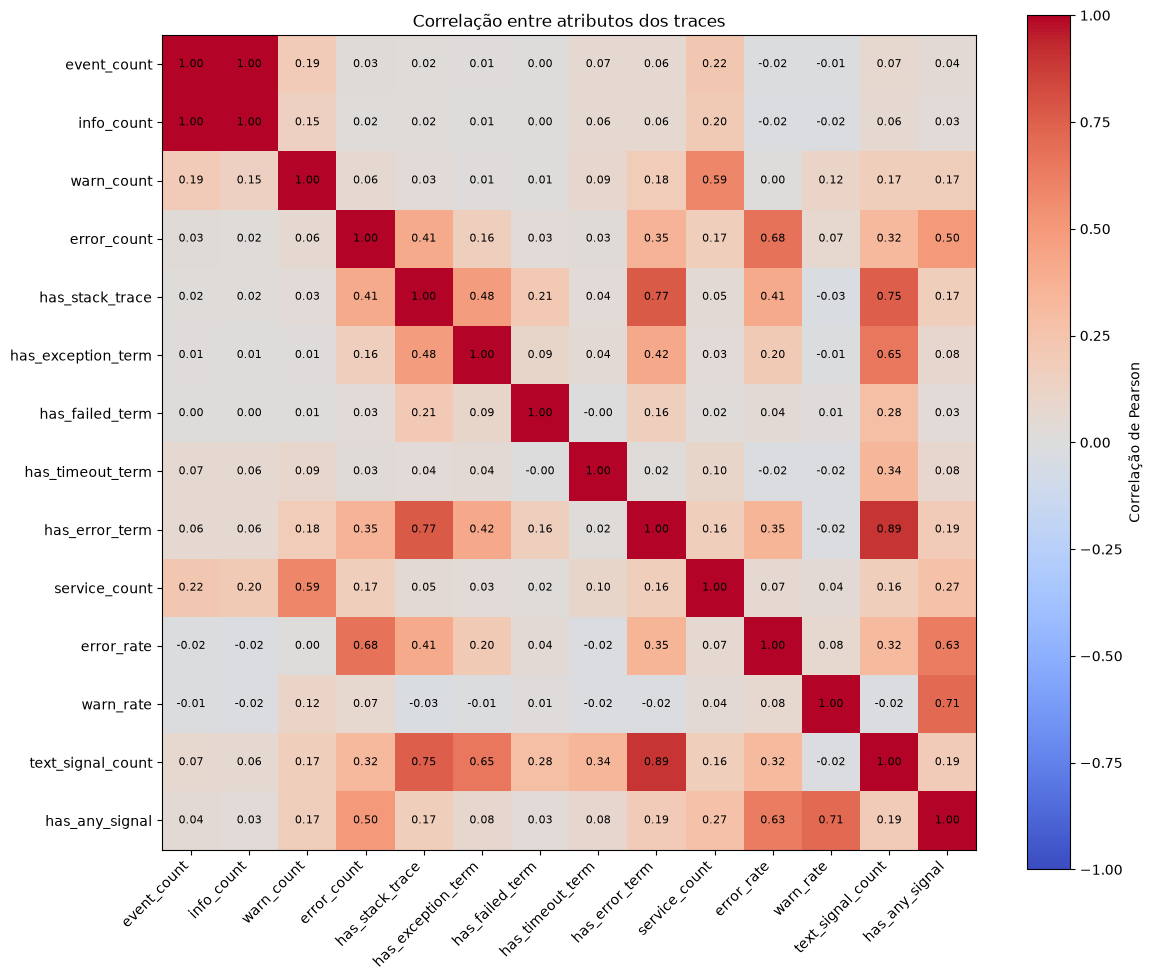

In [9]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(
    figsize=(12, 10)
)

image = ax.imshow(
    correlation,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)

ax.set_xticks(
    np.arange(len(correlation.columns))
)

ax.set_yticks(
    np.arange(len(correlation.index))
)

ax.set_xticklabels(
    correlation.columns,
    rotation=45,
    ha="right",
)

ax.set_yticklabels(
    correlation.index
)

for i in range(correlation.shape[0]):
    for j in range(correlation.shape[1]):
        value = correlation.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=8,
        )

fig.colorbar(
    image,
    ax=ax,
    label="Correlação de Pearson",
)

ax.set_title(
    "Correlação entre atributos dos traces"
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "feature_correlation_heatmap.png",
    dpi=300,
)

plt.show()